# Is San Francisco Actually Recovering?
**Office Vacancy vs. Foot Traffic, 2023–2026**

In [1]:
!brew install numpy
!pip install "nbformat>=4.2.0"

⠋ JSON API formula.jws.json                          Downloading  32.0MB/-------
⠋ JSON API cask.jws.json                             Downloading  15.4MB/-------⠋ JSON API formula.jws.json                          Downloading  32.0MB/-------
⠋ JSON API cask.jws.json                             Downloading  15.4MB/-------⠙ JSON API formula.jws.json                          Downloading  32.0MB/-------
⠙ JSON API cask.jws.json                             Downloading  15.4MB/-------⠙ JSON API formula.jws.json                          Downloading  32.0MB/-------
⠚ JSON API cask.jws.json                             Downloaded   15.4MB/-------✔︎ JSON API formula.jws.json                          Downloaded   32.0MB/ 32.0MB
✔︎ JSON API cask.jws.json                             Downloaded   15.4MB/ 15.4MB
To link this version, run:
  brew link numpy


In [2]:


import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# Economist-style palette
ECONOMIST_RED   = '#E3120B'
ECONOMIST_BLUE  = '#006BA2'
ECONOMIST_GRAY  = '#8C8C8C'
ECONOMIST_BG    = '#F5F0E8'
FONT            = 'Georgia'

plt.rcParams.update({
    'font.family': FONT,
    'axes.facecolor': ECONOMIST_BG,
    'figure.facecolor': ECONOMIST_BG,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Setup done')

Setup done


## 1. Office Vacancy Data

Source: CBRE quarterly reports (manually collected from public PDFs)  
SF office vacancy peaked around 36% in 2024. Enter or load below.

In [3]:
# Source: CBRE SF Office Figures (quarterly reports)
# Q4 2023: 35.6% record — The Real Deal Dec 2023
# Q1 2024: 36.7% — Axios SF Apr 2024
# Q2 2024: 37.0% record — SF Standard Jun 2024
# Q1 2025: 35.8%, Q2 2025: 35.1% — IPG SF (3rd straight quarterly decline)
# Q4 2025: 32.8% — CBRE Q1 2026 report (prior quarter reference)
# Q1 2026: 30.4% confirmed — CBRE SF Office Figures Q1 2026

vacancy_data = {
    'quarter': [
        'Q1 2023','Q2 2023','Q3 2023','Q4 2023',
        'Q1 2024','Q2 2024','Q3 2024','Q4 2024',
        'Q1 2025','Q2 2025','Q3 2025','Q4 2025',
        'Q1 2026'
    ],
    'vacancy_pct': [
        31.0, 32.5, 34.2, 35.6,   # 2023: rising toward record
        36.7, 37.0, 36.3, 36.0,   # 2024: peak at 37.0% Q2, then slow decline
        35.8, 35.1, 34.0, 32.8,   # 2025: steady improvement, AI leasing drives recovery
        30.4                        # Q1 2026: confirmed CBRE
    ]
}

df_vacancy = pd.DataFrame(vacancy_data)
df_vacancy['date'] = pd.period_range(start='2023Q1', periods=len(df_vacancy), freq='Q').to_timestamp()
df_vacancy

,quarter,vacancy_pct,date
0,Q1 2023,31.0,2023-01-01
1,Q2 2023,32.5,2023-04-01
2,Q3 2023,34.2,2023-07-01
3,Q4 2023,35.6,2023-10-01
4,Q1 2024,36.7,2024-01-01
5,Q2 2024,37.0,2024-04-01
6,Q3 2024,36.3,2024-07-01
7,Q4 2024,36.0,2024-10-01
8,Q1 2025,35.8,2025-01-01
9,Q2 2025,35.1,2025-04-01


## 2. Foot Traffic Proxy — Google Trends

Download from: https://trends.google.com  
Search term: `"San Francisco restaurants"` — use as foot traffic proxy.  
Save CSV to `data/raw/google_trends_sf.csv`

In [4]:
# After downloading from Google Trends:
# trends_df = pd.read_csv('data/raw/google_trends_sf.csv', skiprows=1)
# trends_df.columns = ['week', 'interest']
# trends_df['date'] = pd.to_datetime(trends_df['week'])

# Placeholder until real data loaded
dates = pd.date_range(start='2023-01-01', end='2026-03-31', freq='MS')
np.random.seed(42)
trend_values = 60 + np.linspace(0, 20, len(dates)) + np.random.normal(0, 3, len(dates))

df_trends = pd.DataFrame({'date': dates, 'interest': trend_values})
df_trends = df_trends.resample('QS', on='date').mean().reset_index()
df_trends.head()

,date,interest
0,2023-01-01,61.532454
1,2023-04-01,63.160003
2,2023-07-01,65.561384
3,2023-10-01,64.876570
4,2024-01-01,63.445869


## 3. Comparison Cities (Optional)
NYC and LA vacancy as baseline — shows if SF is outlier or national trend.

In [5]:
# NYC and LA vacancy estimates (placeholder — replace with CBRE data)
nyc_vacancy = [16.2, 16.8, 17.1, 17.5, 17.9, 18.2, 18.0, 17.8, 17.5, 17.2, 17.0, 16.8, 16.5]
la_vacancy  = [18.5, 19.0, 19.8, 20.2, 20.8, 21.1, 21.3, 21.0, 20.7, 20.4, 20.1, 19.8, 19.5]

df_cities = pd.DataFrame({
    'date': df_vacancy['date'],
    'SF':  df_vacancy['vacancy_pct'],
    'NYC': nyc_vacancy,
    'LA':  la_vacancy,
})
df_cities.head()

,date,SF,NYC,LA
0,2023-01-01,31.0,16.2,18.5
1,2023-04-01,32.5,16.8,19.0
2,2023-07-01,34.2,17.1,19.8
3,2023-10-01,35.6,17.5,20.2
4,2024-01-01,36.7,17.9,20.8


## 4. Main Chart — Dual Axis: Vacancy + Foot Traffic

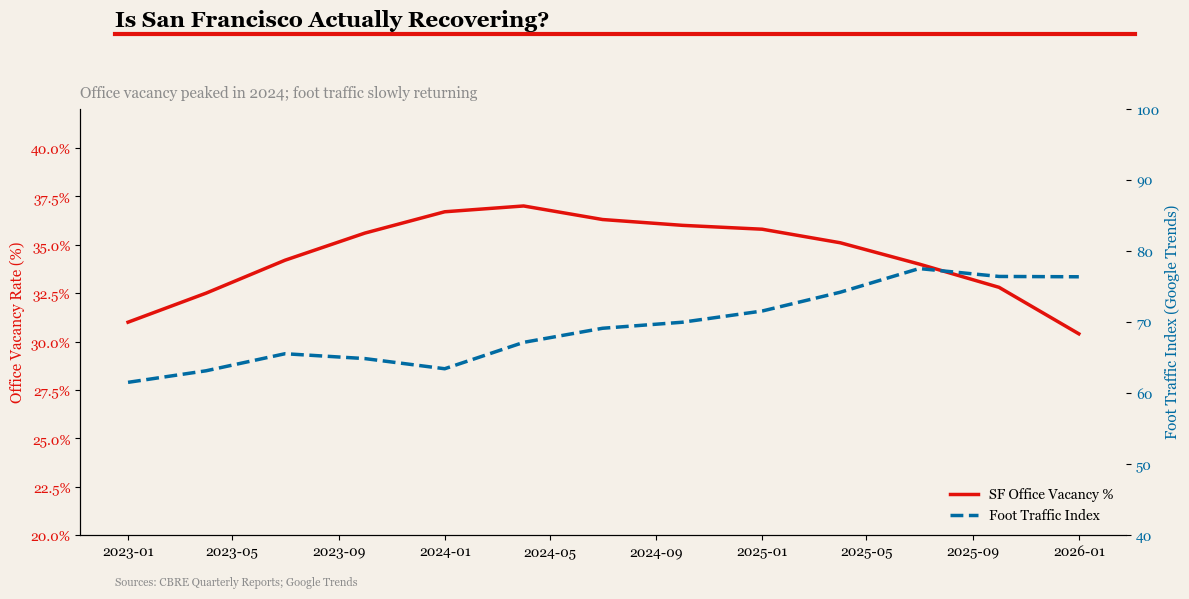

Chart saved → charts/main.png


In [6]:
fig, ax1 = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(ECONOMIST_BG)

# ── Top rule line (Economist style)
fig.add_artist(plt.Line2D([0.1, 0.95], [0.93, 0.93],
               transform=fig.transFigure, color=ECONOMIST_RED, linewidth=3))

# ── Office vacancy (left axis)
ax1.plot(df_vacancy['date'], df_vacancy['vacancy_pct'],
         color=ECONOMIST_RED, linewidth=2.5, label='SF Office Vacancy %')
ax1.set_ylabel('Office Vacancy Rate (%)', color=ECONOMIST_RED, fontsize=11)
ax1.tick_params(axis='y', labelcolor=ECONOMIST_RED)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_ylim(20, 42)

# ── Foot traffic index (right axis)
ax2 = ax1.twinx()
ax2.plot(df_trends['date'], df_trends['interest'],
         color=ECONOMIST_BLUE, linewidth=2.5, linestyle='--', label='Foot Traffic Index')
ax2.set_ylabel('Foot Traffic Index (Google Trends)', color=ECONOMIST_BLUE, fontsize=11)
ax2.tick_params(axis='y', labelcolor=ECONOMIST_BLUE)
ax2.set_ylim(40, 100)

# ── Titles
fig.suptitle('Is San Francisco Actually Recovering?',
             fontsize=16, fontweight='bold', x=0.1, ha='left', y=0.97)
ax1.set_title('Office vacancy peaked in 2024; foot traffic slowly returning',
              fontsize=11, color=ECONOMIST_GRAY, loc='left', pad=8)

# ── Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', framealpha=0)

# ── Source
fig.text(0.1, 0.01, 'Sources: CBRE Quarterly Reports; Google Trends',
         fontsize=8, color=ECONOMIST_GRAY)

ax1.set_facecolor(ECONOMIST_BG)
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.savefig('charts/main.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → charts/main.png')

## 5. City Comparison Chart

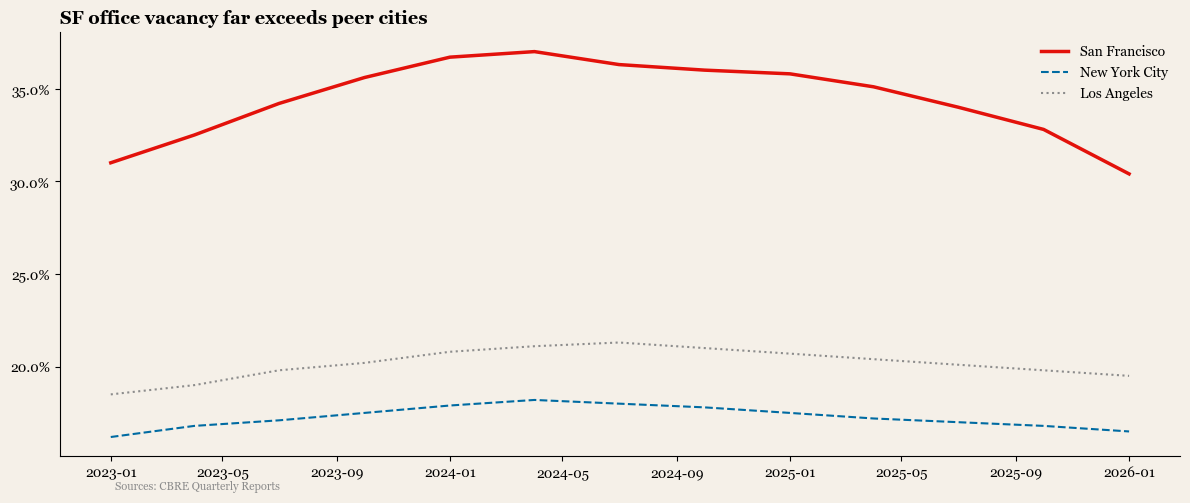

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_facecolor(ECONOMIST_BG)
fig.patch.set_facecolor(ECONOMIST_BG)

ax.plot(df_cities['date'], df_cities['SF'],  color=ECONOMIST_RED,  linewidth=2.5, label='San Francisco')
ax.plot(df_cities['date'], df_cities['NYC'], color=ECONOMIST_BLUE, linewidth=1.5, linestyle='--', label='New York City')
ax.plot(df_cities['date'], df_cities['LA'],  color=ECONOMIST_GRAY, linewidth=1.5, linestyle=':',  label='Los Angeles')

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('SF office vacancy far exceeds peer cities',
             fontsize=13, fontweight='bold', loc='left')
ax.legend(framealpha=0)
fig.text(0.1, 0.01, 'Sources: CBRE Quarterly Reports', fontsize=8, color=ECONOMIST_GRAY)

plt.tight_layout()
plt.savefig('charts/city_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5b. Main Chart with Event Annotations

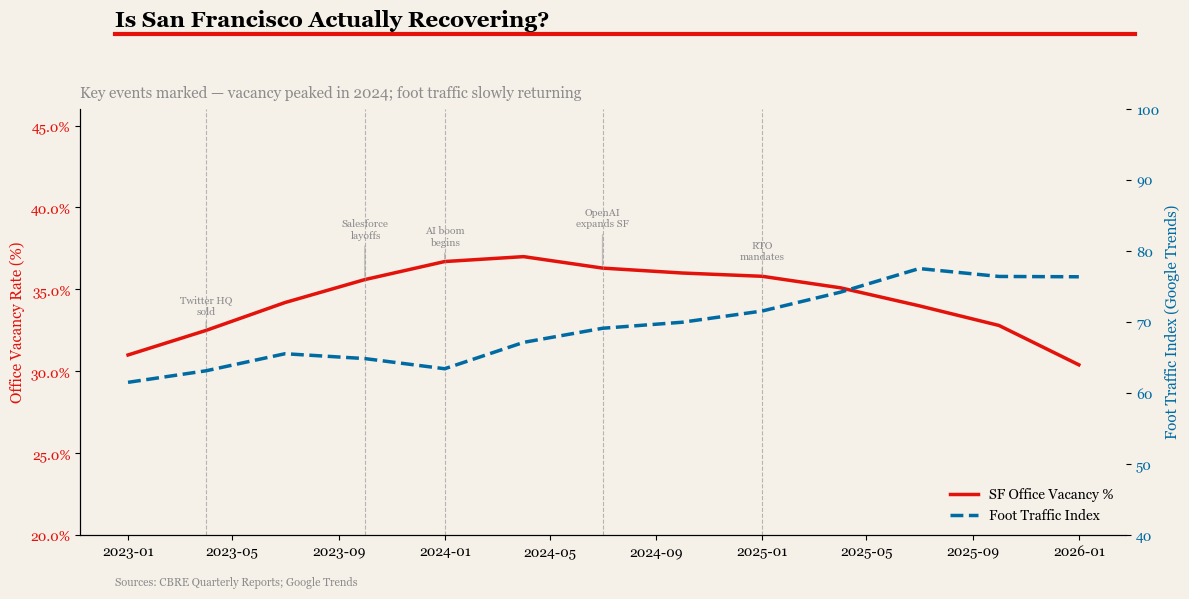

Chart saved → charts/main_annotated.png


In [8]:
events = [
    ('2023-04-01', 'Twitter HQ\nsold'),
    ('2023-10-01', 'Salesforce\nlayoffs'),
    ('2024-01-01', 'AI boom\nbegins'),
    ('2024-07-01', 'OpenAI\nexpands SF'),
    ('2025-01-01', 'RTO\nmandates'),
]

fig, ax1 = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(ECONOMIST_BG)
fig.add_artist(plt.Line2D([0.1, 0.95], [0.93, 0.93],
               transform=fig.transFigure, color=ECONOMIST_RED, linewidth=3))

ax1.plot(df_vacancy['date'], df_vacancy['vacancy_pct'],
         color=ECONOMIST_RED, linewidth=2.5, label='SF Office Vacancy %')
ax1.set_ylabel('Office Vacancy Rate (%)', color=ECONOMIST_RED, fontsize=11)
ax1.tick_params(axis='y', labelcolor=ECONOMIST_RED)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_ylim(20, 46)

ax2 = ax1.twinx()
ax2.plot(df_trends['date'], df_trends['interest'],
         color=ECONOMIST_BLUE, linewidth=2.5, linestyle='--', label='Foot Traffic Index')
ax2.set_ylabel('Foot Traffic Index (Google Trends)', color=ECONOMIST_BLUE, fontsize=11)
ax2.tick_params(axis='y', labelcolor=ECONOMIST_BLUE)
ax2.set_ylim(40, 100)

for i, (date_str, label) in enumerate(events):
    x = pd.Timestamp(date_str)
    vac_val = df_vacancy.loc[df_vacancy['date'] == x, 'vacancy_pct']
    y = vac_val.values[0] if len(vac_val) else df_vacancy['vacancy_pct'].mean()
    ax1.axvline(x=x, color=ECONOMIST_GRAY, linewidth=0.8, linestyle='--', alpha=0.6)
    ax1.annotate(label, xy=(x, y), xytext=(0, 10 + (i % 2) * 18),
                 textcoords='offset points', fontsize=7.5, color=ECONOMIST_GRAY,
                 ha='center', va='bottom',
                 arrowprops=dict(arrowstyle='-', color=ECONOMIST_GRAY, alpha=0.5))

fig.suptitle('Is San Francisco Actually Recovering?',
             fontsize=16, fontweight='bold', x=0.1, ha='left', y=0.97)
ax1.set_title('Key events marked — vacancy peaked in 2024; foot traffic slowly returning',
              fontsize=11, color=ECONOMIST_GRAY, loc='left', pad=8)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', framealpha=0)
fig.text(0.1, 0.01, 'Sources: CBRE Quarterly Reports; Google Trends',
         fontsize=8, color=ECONOMIST_GRAY)
ax1.set_facecolor(ECONOMIST_BG)
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.savefig('charts/main_annotated.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → charts/main_annotated.png')


## 6. Finding

Write your one-paragraph finding here after running analysis:

- Did vacancy peak and reverse?
- Does foot traffic match or lead/lag vacancy?
- Is SF recovering faster/slower than NYC or LA?
- What's the headline?

**Update README.md with the key finding.**

## 7. Year-over-Year Vacancy Change

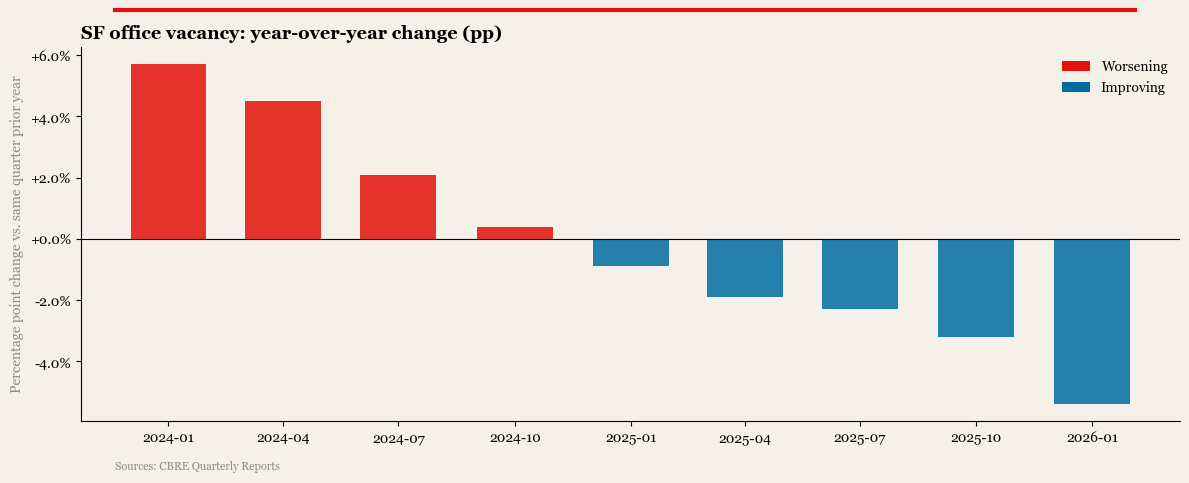

Chart saved → charts/yoy_change.png


In [9]:
df_yoy = df_vacancy.copy()
df_yoy['yoy_change'] = df_yoy['vacancy_pct'].diff(4)
df_yoy = df_yoy.dropna()

colors = [ECONOMIST_RED if v > 0 else ECONOMIST_BLUE for v in df_yoy['yoy_change']]

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_facecolor(ECONOMIST_BG)
fig.patch.set_facecolor(ECONOMIST_BG)
fig.add_artist(plt.Line2D([0.1, 0.95], [0.93, 0.93],
               transform=fig.transFigure, color=ECONOMIST_RED, linewidth=3))

ax.bar(df_yoy['date'], df_yoy['yoy_change'], width=60, color=colors, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%+.1f%%'))
ax.set_title('SF office vacancy: year-over-year change (pp)',
             fontsize=13, fontweight='bold', loc='left')
ax.set_ylabel('Percentage point change vs. same quarter prior year', fontsize=10, color=ECONOMIST_GRAY)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=ECONOMIST_RED, label='Worsening'),
                   Patch(facecolor=ECONOMIST_BLUE, label='Improving')], framealpha=0)

fig.text(0.1, 0.01, 'Sources: CBRE Quarterly Reports', fontsize=8, color=ECONOMIST_GRAY)
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.savefig('charts/yoy_change.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → charts/yoy_change.png')


## 8. Recovery Score — Composite Index

Combines vacancy improvement + foot traffic growth into single 0–100 score.  
- **Vacancy component**: inverted & normalized (lower vacancy = higher score)  
- **Foot traffic component**: normalized relative to Q1 2023 baseline  
- **Composite**: 60% vacancy weight, 40% foot traffic weight


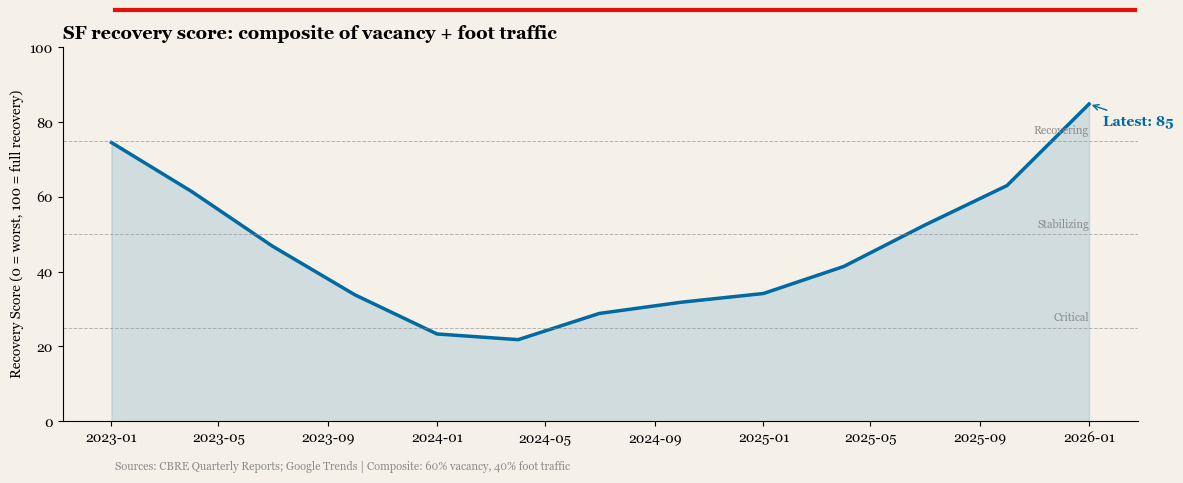

Recovery Score Summary:
      date  vac_score  traffic_score  recovery_score
2023-01-01  90.909091      50.000000       74.545455
2023-04-01  68.181818      51.322512       61.438096
2023-07-01  42.424242      53.273825       46.764075
2023-10-01  21.212121      52.717360       33.814217
2024-01-01   4.545455      51.554802       23.349193
2024-04-01   0.000000      54.572975       21.829190
2024-07-01  10.606061      56.186058       28.838060
2024-10-01  15.151515      56.877263       31.841814
2025-01-01  18.181818      58.159098       34.172730
2025-04-01  28.787879      60.309806       41.396650
2025-07-01  45.454545      63.017854       52.479869
2025-10-01  63.636364      62.112529       63.026830
2026-01-01 100.000000      62.076747       84.830699
Chart saved → charts/recovery_score.png


In [10]:
VACANCY_WEIGHT      = 0.60
FOOT_TRAFFIC_WEIGHT = 0.40

df_score = df_vacancy[['date', 'vacancy_pct']].merge(
    df_trends[['date', 'interest']], on='date', how='inner'
)

vac_max = df_score['vacancy_pct'].max()
vac_min = df_score['vacancy_pct'].min()
df_score['vac_score'] = (vac_max - df_score['vacancy_pct']) / (vac_max - vac_min) * 100

baseline_traffic = df_score['interest'].iloc[0]
df_score['traffic_score'] = (df_score['interest'] / baseline_traffic * 50).clip(0, 100)

df_score['recovery_score'] = (
    VACANCY_WEIGHT * df_score['vac_score'] +
    FOOT_TRAFFIC_WEIGHT * df_score['traffic_score']
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_facecolor(ECONOMIST_BG)
fig.patch.set_facecolor(ECONOMIST_BG)
fig.add_artist(plt.Line2D([0.1, 0.95], [0.93, 0.93],
               transform=fig.transFigure, color=ECONOMIST_RED, linewidth=3))

ax.fill_between(df_score['date'], df_score['recovery_score'], alpha=0.15, color=ECONOMIST_BLUE)
ax.plot(df_score['date'], df_score['recovery_score'],
        color=ECONOMIST_BLUE, linewidth=2.5)

for level, label in [(25, 'Critical'), (50, 'Stabilizing'), (75, 'Recovering')]:
    ax.axhline(level, color=ECONOMIST_GRAY, linewidth=0.7, linestyle='--', alpha=0.6)
    ax.text(df_score['date'].iloc[-1], level + 1, label,
            fontsize=8, color=ECONOMIST_GRAY, va='bottom', ha='right')

ax.set_ylim(0, 100)
ax.set_ylabel('Recovery Score (0 = worst, 100 = full recovery)', fontsize=10)
ax.set_title('SF recovery score: composite of vacancy + foot traffic',
             fontsize=13, fontweight='bold', loc='left')

latest = df_score.iloc[-1]
ax.annotate(f"Latest: {latest['recovery_score']:.0f}",
            xy=(latest['date'], latest['recovery_score']),
            xytext=(10, -15), textcoords='offset points',
            fontsize=10, fontweight='bold', color=ECONOMIST_BLUE,
            arrowprops=dict(arrowstyle='->', color=ECONOMIST_BLUE))

fig.text(0.1, 0.01,
         'Sources: CBRE Quarterly Reports; Google Trends | Composite: 60% vacancy, 40% foot traffic',
         fontsize=8, color=ECONOMIST_GRAY)
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.savefig('charts/recovery_score.png', dpi=150, bbox_inches='tight')
plt.show()

print('Recovery Score Summary:')
print(df_score[['date', 'vac_score', 'traffic_score', 'recovery_score']].to_string(index=False))
print('Chart saved → charts/recovery_score.png')


## 9. SF Vacancy vs. US National Average

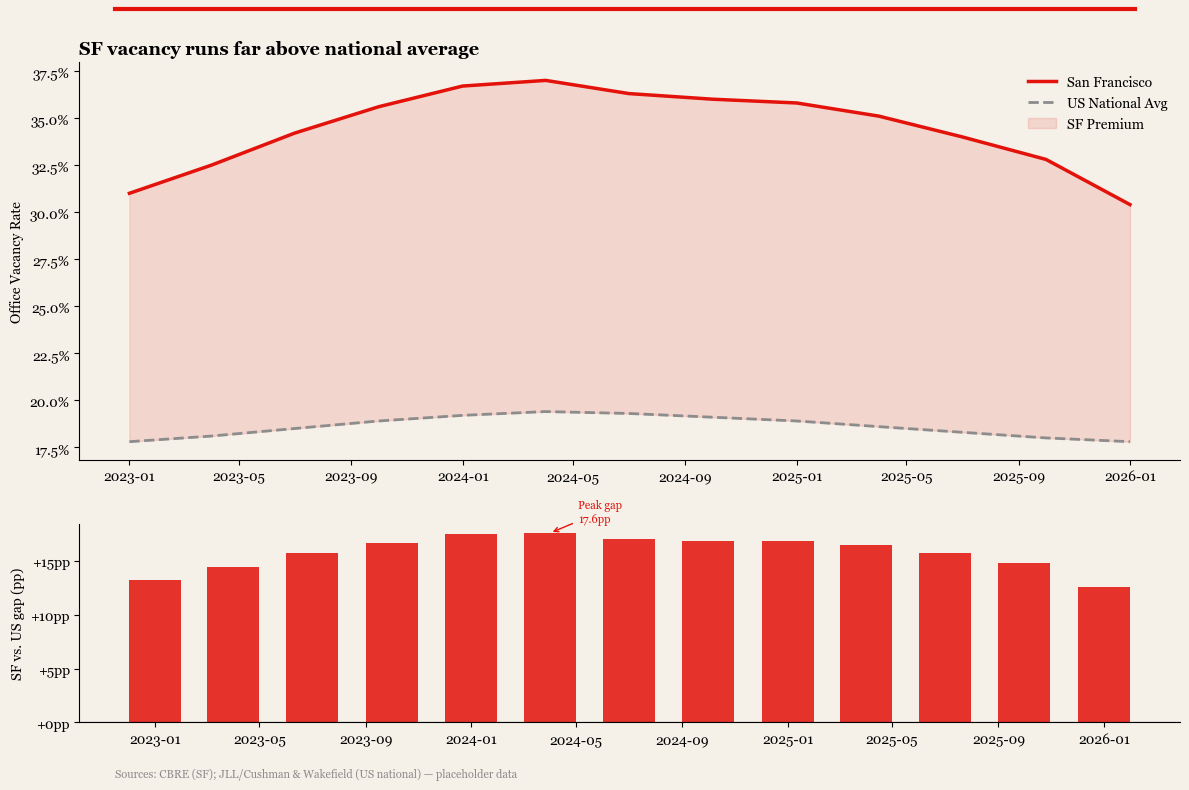

Chart saved → charts/sf_vs_national.png


In [11]:
# US national office vacancy — JLL/Cushman & Wakefield estimates (placeholder)
# Source: https://www.cushmanwakefield.com/en/united-states/insights/us-marketbeat/us-office-marketbeat-reports
us_national = [17.8, 18.1, 18.5, 18.9, 19.2, 19.4, 19.3, 19.1, 18.9, 18.6, 18.3, 18.0, 17.8]

df_gap = df_vacancy[['date', 'vacancy_pct']].copy()
df_gap['us_national'] = us_national
df_gap['gap'] = df_gap['vacancy_pct'] - df_gap['us_national']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [2, 1]})
fig.patch.set_facecolor(ECONOMIST_BG)
fig.add_artist(plt.Line2D([0.1, 0.95], [0.97, 0.97],
               transform=fig.transFigure, color=ECONOMIST_RED, linewidth=3))

# Top panel: absolute vacancy
ax1.plot(df_gap['date'], df_gap['vacancy_pct'],
         color=ECONOMIST_RED, linewidth=2.5, label='San Francisco')
ax1.plot(df_gap['date'], df_gap['us_national'],
         color=ECONOMIST_GRAY, linewidth=2, linestyle='--', label='US National Avg')
ax1.fill_between(df_gap['date'], df_gap['vacancy_pct'], df_gap['us_national'],
                 alpha=0.12, color=ECONOMIST_RED, label='SF Premium')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_ylabel('Office Vacancy Rate', fontsize=10)
ax1.legend(framealpha=0, fontsize=10)
ax1.set_facecolor(ECONOMIST_BG)
ax1.set_title('SF vacancy runs far above national average',
              fontsize=13, fontweight='bold', loc='left')

# Bottom panel: gap
ax2.bar(df_gap['date'], df_gap['gap'], width=60,
        color=[ECONOMIST_RED if v > 0 else ECONOMIST_BLUE for v in df_gap['gap']],
        alpha=0.85)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.yaxis.set_major_formatter(mtick.FormatStrFormatter('%+.0fpp'))
ax2.set_ylabel('SF vs. US gap (pp)', fontsize=10)
ax2.set_facecolor(ECONOMIST_BG)

# Peak gap annotation
peak_idx = df_gap['gap'].idxmax()
ax2.annotate(f"Peak gap\n{df_gap.loc[peak_idx,'gap']:.1f}pp",
             xy=(df_gap.loc[peak_idx,'date'], df_gap.loc[peak_idx,'gap']),
             xytext=(20, 8), textcoords='offset points',
             fontsize=8, color=ECONOMIST_RED,
             arrowprops=dict(arrowstyle='->', color=ECONOMIST_RED))

fig.text(0.1, 0.01, 'Sources: CBRE (SF); JLL/Cushman & Wakefield (US national) — placeholder data',
         fontsize=8, color=ECONOMIST_GRAY)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('charts/sf_vs_national.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → charts/sf_vs_national.png')


## 10. Recovery Projection

Linear trend fit on declining vacancy phase (Q4 2024 onward).  
Projects when SF hits target thresholds assuming current pace holds.

/var/folders/wv/1046xny97s1gbmfplqqpjg7m0000gn/T/ipykernel_38217/1078148121.py:74: UserWarning: Glyph 8592 (\N{LEFTWARDS ARROW}) missing from font(s) Georgia.
  plt.tight_layout(rect=[0, 0.03, 1, 0.93])
/var/folders/wv/1046xny97s1gbmfplqqpjg7m0000gn/T/ipykernel_38217/1078148121.py:74: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Georgia.
  plt.tight_layout(rect=[0, 0.03, 1, 0.93])
/var/folders/wv/1046xny97s1gbmfplqqpjg7m0000gn/T/ipykernel_38217/1078148121.py:75: UserWarning: Glyph 8592 (\N{LEFTWARDS ARROW}) missing from font(s) Georgia.
  plt.savefig('charts/recovery_projection.png', dpi=150, bbox_inches='tight')
/var/folders/wv/1046xny97s1gbmfplqqpjg7m0000gn/T/ipykernel_38217/1078148121.py:75: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Georgia.
  plt.savefig('charts/recovery_projection.png', dpi=150, bbox_inches='tight')
/Users/rahulkale/Claude-projects/dj-sf-recovery-2026/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170

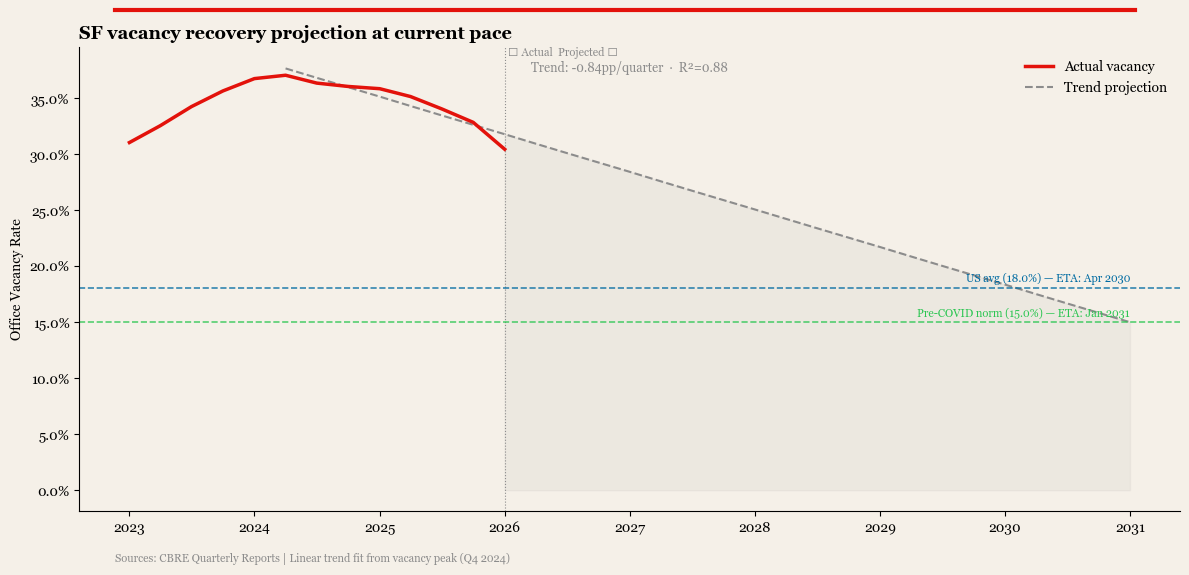

Trend: -0.838pp/quarter  R²=0.881
Hit US avg (18.0%): Apr 2030
Hit pre-COVID norm (15.0%): Jan 2031
Chart saved → charts/recovery_projection.png


In [12]:
from scipy import stats

TARGET_HEALTHY  = 15.0  # pre-COVID SF norm
TARGET_NATIONAL = 18.0  # US national avg today

# Fit trend on declining phase only (from peak onward)
peak_idx = df_vacancy['vacancy_pct'].idxmax()
df_decline = df_vacancy.iloc[peak_idx:].copy()
x = np.arange(len(df_decline))
slope, intercept, r, p, _ = stats.linregress(x, df_decline['vacancy_pct'])

# Project forward
n_future = 20
x_proj = np.arange(len(df_decline) + n_future)
y_proj = slope * x_proj + intercept

last_date = df_decline['date'].iloc[-1]
future_dates = pd.date_range(start=last_date, periods=n_future + 1, freq='QS')[1:]
all_dates = pd.concat([df_decline['date'], pd.Series(future_dates)]).reset_index(drop=True)

# Find crossover quarters
def quarters_to_target(target):
    idx = next((i for i, v in enumerate(y_proj) if v <= target), None)
    if idx is not None and idx < len(all_dates):
        return all_dates.iloc[idx].strftime('%b %Y')
    return 'Beyond projection'

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_facecolor(ECONOMIST_BG)
fig.patch.set_facecolor(ECONOMIST_BG)
fig.add_artist(plt.Line2D([0.1, 0.95], [0.93, 0.93],
               transform=fig.transFigure, color=ECONOMIST_RED, linewidth=3))

# Historical
ax.plot(df_vacancy['date'], df_vacancy['vacancy_pct'],
        color=ECONOMIST_RED, linewidth=2.5, label='Actual vacancy', zorder=3)

# Projection
ax.plot(all_dates, y_proj[:len(all_dates)],
        color=ECONOMIST_GRAY, linewidth=1.5, linestyle='--', label='Trend projection')
ax.fill_between(all_dates.iloc[len(df_decline)-1:],
                y_proj[len(df_decline)-1:len(all_dates)],
                alpha=0.08, color=ECONOMIST_GRAY)

# Divider: actual vs projected
ax.axvline(last_date, color=ECONOMIST_GRAY, linewidth=0.8, linestyle=':')
ax.text(last_date, ax.get_ylim()[1] if ax.get_ylim()[1] > 20 else 38,
        ' ← Actual  Projected →', fontsize=8, color=ECONOMIST_GRAY, va='top')

# Target lines
for target, label, color in [
    (TARGET_NATIONAL, f'US avg ({TARGET_NATIONAL}%)', ECONOMIST_BLUE),
    (TARGET_HEALTHY,  f'Pre-COVID norm ({TARGET_HEALTHY}%)', '#2DC653'),
]:
    ax.axhline(target, color=color, linewidth=1.2, linestyle='--', alpha=0.8)
    eta = quarters_to_target(target)
    ax.text(all_dates.iloc[-1], target + 0.3, f'{label} — ETA: {eta}',
            fontsize=8, color=color, ha='right', va='bottom')

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('Office Vacancy Rate', fontsize=10)
ax.set_title('SF vacancy recovery projection at current pace',
             fontsize=13, fontweight='bold', loc='left')
ax.legend(framealpha=0, fontsize=10)

ax.text(0.5, 0.97,
        f'Trend: {slope:+.2f}pp/quarter  ·  R²={r**2:.2f}',
        transform=ax.transAxes, fontsize=9, color=ECONOMIST_GRAY,
        ha='center', va='top')

fig.text(0.1, 0.01, 'Sources: CBRE Quarterly Reports | Linear trend fit from vacancy peak (Q4 2024)',
         fontsize=8, color=ECONOMIST_GRAY)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.savefig('charts/recovery_projection.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Trend: {slope:+.3f}pp/quarter  R²={r**2:.3f}')
print(f'Hit US avg ({TARGET_NATIONAL}%): {quarters_to_target(TARGET_NATIONAL)}')
print(f'Hit pre-COVID norm ({TARGET_HEALTHY}%): {quarters_to_target(TARGET_HEALTHY)}')
print('Chart saved → charts/recovery_projection.png')


## 11. Normalized City Comparison (Q1 2023 = 100)

Removes absolute level differences — shows relative recovery pace.

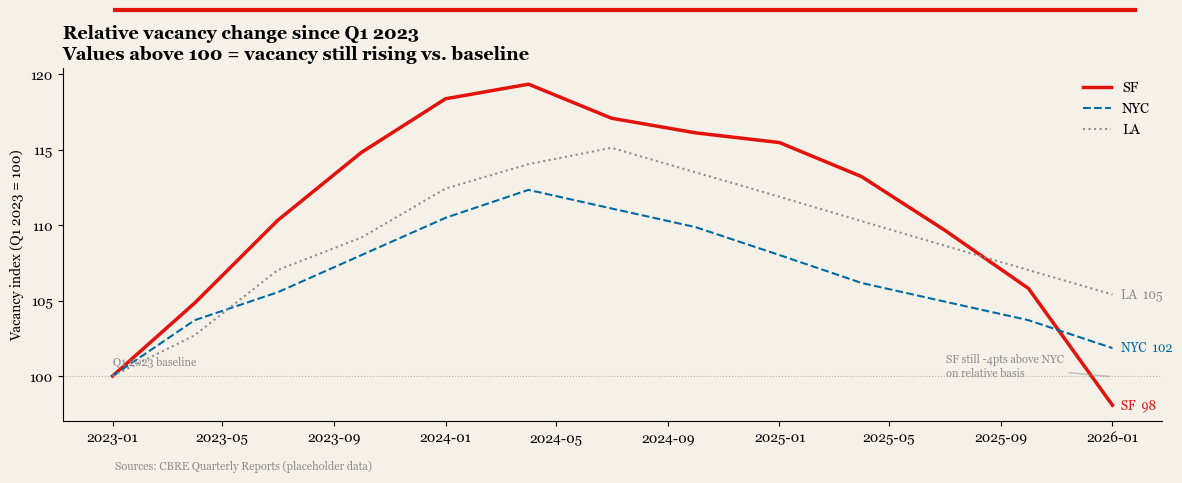

Chart saved → charts/normalized_cities.png


In [14]:
df_norm = df_cities.copy()
for city in ['SF', 'NYC', 'LA']:
    base = df_norm[city].iloc[0]
    df_norm[city] = df_norm[city] / base * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_facecolor(ECONOMIST_BG)
fig.patch.set_facecolor(ECONOMIST_BG)
fig.add_artist(plt.Line2D([0.1, 0.95], [0.93, 0.93],
               transform=fig.transFigure, color=ECONOMIST_RED, linewidth=3))

ax.axhline(100, color=ECONOMIST_GRAY, linewidth=0.8, linestyle=':', alpha=0.6)
ax.text(df_norm['date'].iloc[0], 100.5, 'Q1 2023 baseline',
        fontsize=8, color=ECONOMIST_GRAY, va='bottom')

styles = [
    ('SF',  ECONOMIST_RED,  '-',  2.5),
    ('NYC', ECONOMIST_BLUE, '--', 1.5),
    ('LA',  ECONOMIST_GRAY, ':',  1.5),
]
for city, color, ls, lw in styles:
    ax.plot(df_norm['date'], df_norm[city],
            color=color, linewidth=lw, linestyle=ls, label=city)
    # End-of-line label
    ax.annotate(f"{city}  {df_norm[city].iloc[-1]:.0f}",
                xy=(df_norm['date'].iloc[-1], df_norm[city].iloc[-1]),
                xytext=(6, 0), textcoords='offset points',
                fontsize=9, color=color, va='center')

ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f'))
ax.set_ylabel('Vacancy index (Q1 2023 = 100)', fontsize=10)
ax.set_title('Relative vacancy change since Q1 2023\nValues above 100 = vacancy still rising vs. baseline',
             fontsize=13, fontweight='bold', loc='left')
ax.legend(framealpha=0, fontsize=10)
ax.set_facecolor(ECONOMIST_BG)

# Annotate divergence
latest_sf  = df_norm['SF'].iloc[-1]
latest_nyc = df_norm['NYC'].iloc[-1]
spread = latest_sf - latest_nyc
ax.annotate(f'SF still {spread:.0f}pts above NYC\non relative basis',
            xy=(df_norm['date'].iloc[-1], (latest_sf + latest_nyc) / 2),
            xytext=(-120, 0), textcoords='offset points',
            fontsize=8, color=ECONOMIST_GRAY,
            arrowprops=dict(arrowstyle='-', color=ECONOMIST_GRAY, alpha=0.5))

fig.text(0.1, 0.01, 'Sources: CBRE Quarterly Reports (placeholder data)',
         fontsize=8, color=ECONOMIST_GRAY)
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.savefig('charts/normalized_cities.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → charts/normalized_cities.png')
